# Data Exploration and Processing
This part handles missing values, cleaning from unnecessary attributes 

In [33]:
!pip install "transformers>=4.30.0,<4.37.3"
!pip install "tensorflow>=2.12.0,<2.16.0"
!pip install "torch>=2.0.0,<2.3.0"
!pip install "scikit-learn==1.4.0"
!pip install "numpy>=1.24.0,<1.26.1"
!pip install "polars==0.20.8"
!pip install "pyyaml==6.0.1"
!pip install tqdm

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [34]:
from pathlib import Path
import polars as pl
from transformers import AutoTokenizer, AutoModel
import tensorflow as tf


from ebrec.utils._polars import slice_join_dataframes
from ebrec.utils._behaviors import (
    create_binary_labels_column,
    sampling_strategy_wu2019,
    truncate_history
)
        
from ebrec.utils._constants import (
    DEFAULT_HISTORY_ARTICLE_ID_COL,
    DEFAULT_CLICKED_ARTICLES_COL,
    DEFAULT_INVIEW_ARTICLES_COL,
    DEFAULT_IMPRESSION_ID_COL,
    DEFAULT_SUBTITLE_COL,
    DEFAULT_LABELS_COL,
    DEFAULT_TITLE_COL,
    DEFAULT_USER_COL
)

from ebrec.utils._behaviors import (
    create_binary_labels_column,
    sampling_strategy_wu2019,
    add_known_user_column,
    add_prediction_scores,
    truncate_history
)

from ebrec.utils._descriptive_analysis import (
    min_max_impression_time_behaviors, 
    min_max_impression_time_history
)

from ebrec.evaluation import MetricEvaluator, AucScore, NdcgScore, MrrScore
from ebrec.utils._articles import convert_text2encoding_with_transformers
from ebrec.utils._polars import concat_str_columns, slice_join_dataframes
from ebrec.utils._articles import create_article_id_to_value_mapping
from ebrec.utils._nlp import get_transformers_word_embeddings
from ebrec.utils._python import write_submission_file, rank_predictions_by_score

In [35]:
PATH = Path("ebnerd_data")
data_split_train = "ebnerd_small/train"

# Due to the big size of large dataset, there were some issues while uploading. These lines can be uncommented once the datasets are uploaded on the specified paths
# data_split_train = "ebnerd_large/train"
data_split_validate = "ebnerd_small/validation"
# data_split_validate = "ebnerd_large/validation"

# The same issue is addressed regarding the testset dataset
# data_test = "ebnerd_testset/test"

In [36]:
def scan_data(data_split, behaviors_file, history_file):
    
    behaviors_df = pl.scan_parquet(PATH.joinpath(data_split, behaviors_file)).collect()
    history_df = pl.scan_parquet(PATH.joinpath(data_split, history_file)).collect()
    
    return behaviors_df, history_df

In [37]:
# Scan training data
df_behaviors, df_history = scan_data(data_split_train, "behaviors.parquet", "history.parquet")

# Scan validation data
df_behaviors_v, df_history_v = scan_data(data_split_validate, "behaviors.parquet", "history.parquet")

# Scan test data
# df_behaviors_t, df_history_t = scan_data(data_test, "behaviors.parquet", "history.parquet")


# Scan articles_train_validate

parquet_file_t_v = PATH / "articles.parquet"
df_articles = pl.scan_parquet(str(parquet_file_t_v)).collect()

# parquet_file_t_v = PATH / "ebnerd_large/articles.parquet"
# df_articles = pl.scan_parquet(str(parquet_file_t_v)).collect()
# parquet_file_t = PATH / "ebnerd_testset/articles.parquet"
# df_articles_t = pl.scan_parquet(str(parquet_file_t)).collect()

### Check for missing values
The following lines will be showing the missing values in order to have a better understanding of the data, as well as decisions for various attributes in the datasets

In [38]:

def convert_to_lists(df):
    columns = df.columns
    data_lists = {col: df[col].to_list() for col in columns}
    return data_lists

def missing_values(df):
    missing = {col: data_list.count(None) for col, data_list in df.items()}
    return missing


In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to pandas
df_pd = df_behaviors.to_pandas()
df_pd_h = df_history.to_pandas()

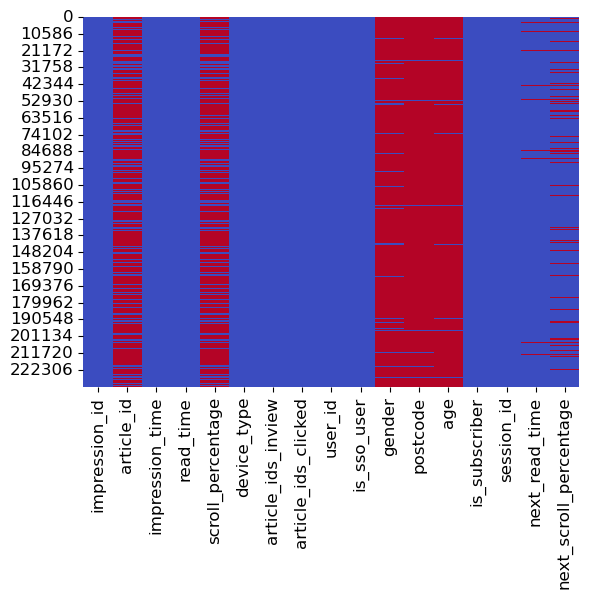

In [40]:

sns.heatmap(df_pd.isnull(), cbar=False, cmap='coolwarm')
plt.show()

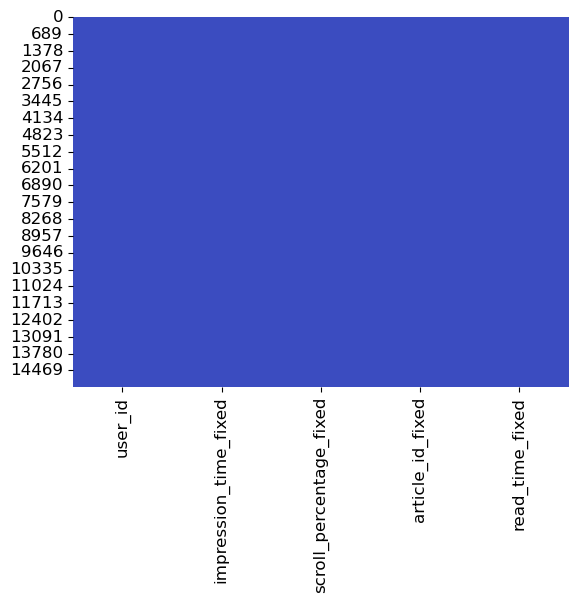

In [41]:

sns.heatmap(df_pd_h.isnull(), cbar=False, cmap='coolwarm')
plt.show()

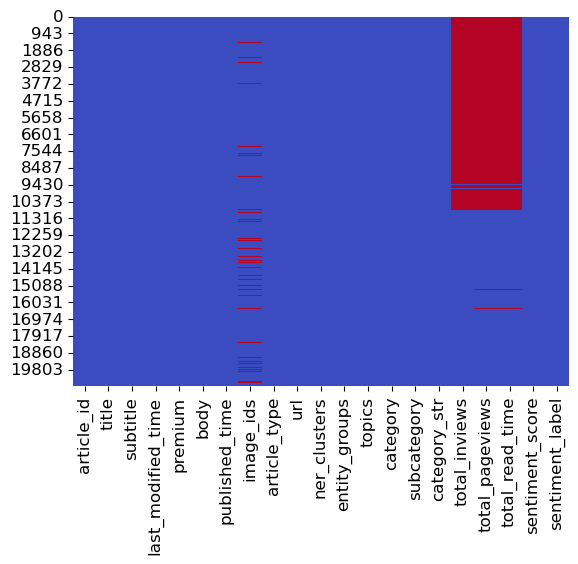

In [42]:
df_pd_a = df_articles.to_pandas()

sns.heatmap(df_pd_a.isnull(), cbar=False, cmap='coolwarm')
plt.show()

/tmp/ipykernel_2519/696271267.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df_pd.corr()


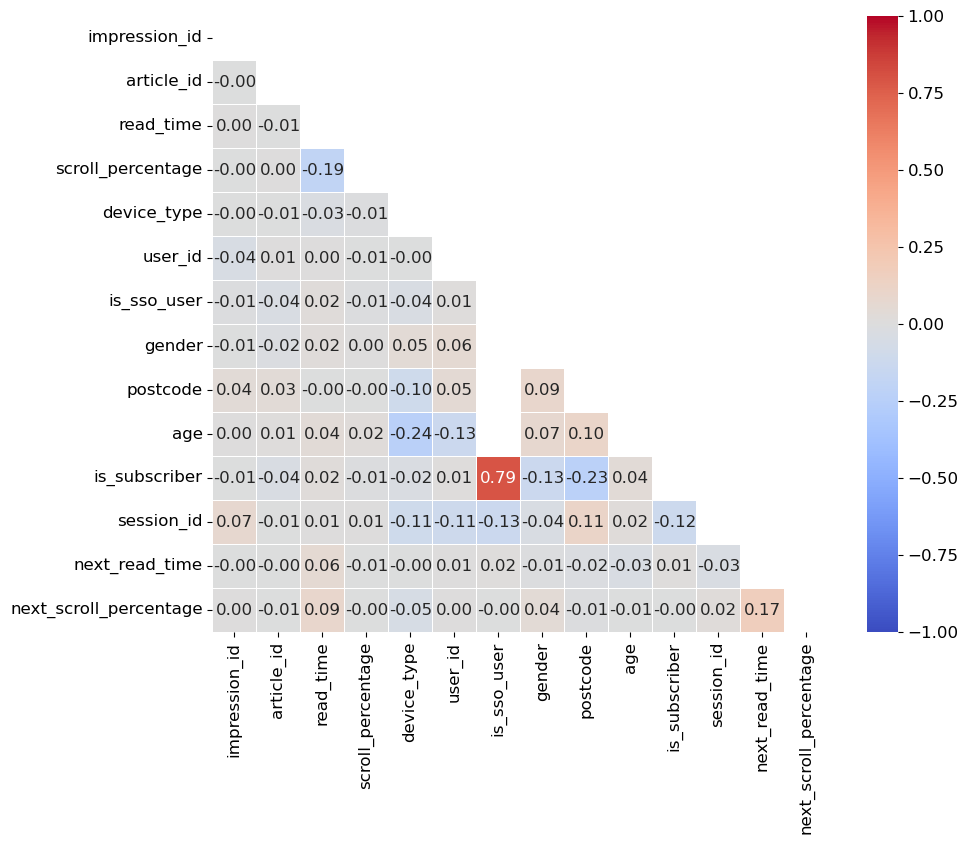

In [43]:
import numpy as np

correlation_matrix = df_pd.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize = (10,8))
plt.rcParams.update({'font.size': 12})
sns.heatmap(correlation_matrix, cmap = 'coolwarm', vmin = -1, vmax = 1, center = 0, annot=True, fmt=".2f", square=True, linewidths=.5, mask = mask)
plt.show()


In [44]:
print(df_pd.isnull().sum())

impression_id                  0
article_id                162466
impression_time                0
read_time                      0
scroll_percentage         163789
device_type                    0
article_ids_inview             0
article_ids_clicked            0
user_id                        0
is_sso_user                    0
gender                    216668
postcode                  228214
age                       226546
is_subscriber                  0
session_id                     0
next_read_time              6218
next_scroll_percentage     26270
dtype: int64


In [45]:
df_pd_v = df_behaviors_v.to_pandas()
df_pd_h_v = df_history_v.to_pandas()
# df_pd_t = df_behaviors_t.to_pandas()
# df_pd_h_t = df_history_t.to_pandas()
print("Validation Behaviors")
print(df_pd_v.isnull().sum())
# print("\nTest Behaviors")
# print(df_pd_t.isnull().sum())
print("\nTrain History")
print(df_pd_h.isnull().sum())
print("\nValidation History")
print(df_pd_h_v.isnull().sum())
# print("\nTest History")
# print(df_pd_h_t.isnull().sum())

Validation Behaviors
impression_id                  0
article_id                173345
impression_time                0
read_time                      0
scroll_percentage         174166
device_type                    0
article_ids_inview             0
article_ids_clicked            0
user_id                        0
is_sso_user                    0
gender                    228336
postcode                  240139
age                       238467
is_subscriber                  0
session_id                     0
next_read_time              6709
next_scroll_percentage     29712
dtype: int64

Train History
user_id                    0
impression_time_fixed      0
scroll_percentage_fixed    0
article_id_fixed           0
read_time_fixed            0
dtype: int64

Validation History
user_id                    0
impression_time_fixed      0
scroll_percentage_fixed    0
article_id_fixed           0
read_time_fixed            0
dtype: int64


In [46]:

# df_pd_a_t = df_articles.to_pandas()

print("Train/Val Articles")
print(df_pd_a.isnull().sum())

# print("\nTest Articles")
# print(df_pd_a_t.isnull().sum())


Train/Val Articles
article_id                0
title                     0
subtitle                  0
last_modified_time        0
premium                   0
body                      0
published_time            0
image_ids              1878
article_type              0
url                       0
ner_clusters              0
entity_groups             0
topics                    0
category                  0
subcategory               0
category_str              0
total_inviews         10770
total_pageviews       10882
total_read_time       10882
sentiment_score           0
sentiment_label           0
dtype: int64


## Analysis
### Behaviors data
- article_id has many missing values, however from the description of data it indicates that the impression has been done of the first page, so even though it is missing it is still important 
- gender, postcode, age and scroll_percentage, next_scroll_percentage columns have many missing values in all datasets 
- We decide to drop gender, postcode, next_read_time and next_scroll_percentage. The two last columns are also refected on the history dataset.
- In case age is kept, we can fill the missing value with the mean value across all the rows. This, because as the age is groupped in bins, it will not make a lot of difference too (protecting the datatype too)
  
### History data
- There are no missing values

### Articles data
- There are missing values for the img_ids, which is a column we can delete. We also think that other columns such as body, url and category_str can be deleted.
- Use text embedding for columns such as title, subtitle. 


In [47]:
import math 
def round_up_to_nearest_10(x):
    return int(math.ceil(x / 10.0)) * 10
    
def fill_missing(df):
    df = df.with_columns([
        pl.when(df['age'].is_null())
            .then(round_up_to_nearest_10(df['age'].mean()))
            .otherwise(df['age'].cast(pl.Int8))
            .alias('age')
    ])
    return df
    

In [48]:
df_behaviors_p = df_behaviors
df_behaviors_p = fill_missing(df_behaviors_p)

df_behaviors_v_p = df_behaviors_v
df_behaviors_v_p = fill_missing(df_behaviors_v)


/tmp/ipykernel_2519/3842106308.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix1 = df_behaviors_p.to_pandas().corr()


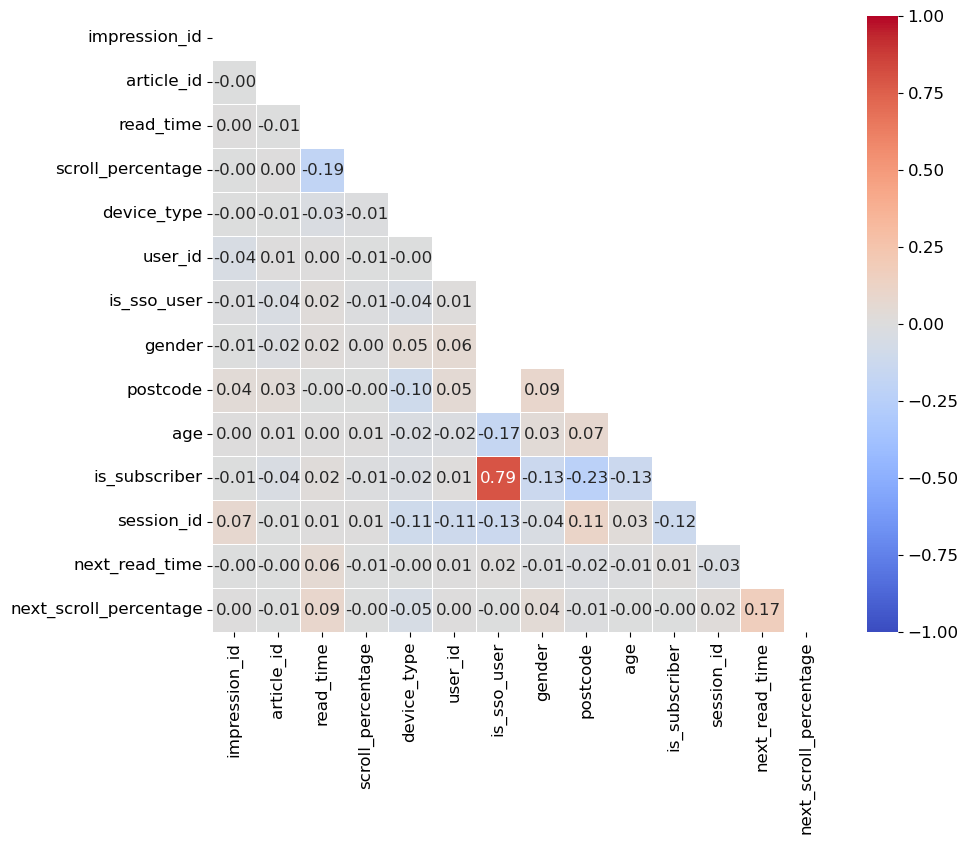

In [49]:

correlation_matrix1 = df_behaviors_p.to_pandas().corr()

mask = np.triu(np.ones_like(correlation_matrix1, dtype=bool))

plt.figure(figsize = (10,8))
plt.rcParams.update({'font.size': 12})
sns.heatmap(correlation_matrix1, cmap = 'coolwarm', vmin = -1, vmax = 1, center = 0, annot=True, fmt=".2f", square=True, linewidths=.5, mask = mask)
plt.show()


The following code does the text embedding 

In [50]:
TRANSFORMER_MODEL_NAME = "FacebookAI/xlm-roberta-base"
TEXT_COLUMNS_TO_USE = [DEFAULT_TITLE_COL, DEFAULT_SUBTITLE_COL]
MAX_TITLE_LENGTH = 30


transformer_model = AutoModel.from_pretrained(TRANSFORMER_MODEL_NAME)
transformer_tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL_NAME)

word2vec_embedding = get_transformers_word_embeddings(transformer_model)

df_articles, cat_cal = concat_str_columns(df_articles, columns=TEXT_COLUMNS_TO_USE)

# Can be run once the testset is uploaded on the specified location
# df_articles_t, cat_cal = concat_str_columns(df_articles_t, columns=TEXT_COLUMNS_TO_USE)

df_articles, token_col_title = convert_text2encoding_with_transformers(
    df_articles, transformer_tokenizer, cat_cal, max_length=MAX_TITLE_LENGTH
)
# df_articles_t, token_col_title = convert_text2encoding_with_transformers(
#     df_articles_t, transformer_tokenizer, cat_cal, max_length=MAX_TITLE_LENGTH
# )
# =>
article_mapping = create_article_id_to_value_mapping(
    df=df_articles, value_col=token_col_title
)

# article_mapping_t = create_article_id_to_value_mapping(
#    df=df_articles_t, value_col=token_col_title
# )


In [51]:
# df_articles.head(2)

### Train data - Ckeck min/max impression time

In [52]:
print(f"Behaviors: {min_max_impression_time_behaviors(df_behaviors)}")
print(f"History: {min_max_impression_time_history(df_history)}")

Behaviors: shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min                 ┆ max                 │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2023-05-18 07:00:01 ┆ 2023-05-25 06:59:58 │
└─────────────────────┴─────────────────────┘
History: shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min                 ┆ max                 │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2023-04-27 07:00:00 ┆ 2023-05-18 06:59:59 │
└─────────────────────┴─────────────────────┘


# Add history to Behaviors 
Regarding train data. 
- Joining between behaviors and history is done through the user_id (DEFAULT_USER_COL)
  

In [53]:
df_history = df_history.select(DEFAULT_USER_COL, DEFAULT_HISTORY_ARTICLE_ID_COL).pipe(
    truncate_history,
    column=DEFAULT_HISTORY_ARTICLE_ID_COL,
    history_size=30,
    padding_value=0,
    enable_warning=False,
)
df_history.head(5)

user_id,article_id_fixed
u32,list[i32]
13538,"[9767342, 9767751, … 9769366]"
14241,"[9763401, 9763250, … 9767852]"
20396,"[9763634, 9763401, … 9769679]"
34912,"[9766722, 9759476, … 9770882]"
37953,"[9762836, 9763942, … 9769306]"


In [54]:
df_all = slice_join_dataframes(
    df1=df_behaviors,
    df2=df_history,
    on=DEFAULT_USER_COL,
    how="left",
 )
df_all.head(5)

impression_id,article_id,impression_time,read_time,scroll_percentage,device_type,article_ids_inview,article_ids_clicked,user_id,is_sso_user,gender,postcode,age,is_subscriber,session_id,next_read_time,next_scroll_percentage,article_id_fixed
u32,i32,datetime[μs],f32,f32,i8,list[i32],list[i32],u32,bool,i8,i8,i8,bool,u32,f32,f32,list[i32]
149474,null,2023-05-24 07:47:53,13.0,null,2,"[9778623, 9778682, … 9778728]",[9778657],139836,false,null,null,null,false,759,7.0,22.0,"[0, 0, … 9765156]"
150528,null,2023-05-24 07:33:25,25.0,null,2,"[9778718, 9778728, … 9778682]",[9778623],143471,false,null,null,null,false,1240,287.0,100.0,"[9767557, 9768062, … 9770989]"
153068,9778682,2023-05-24 07:09:04,78.0,100.0,1,"[9778657, 9778669, … 9778682]",[9778669],151570,false,null,null,null,false,1976,45.0,100.0,"[9770620, 9770594, … 9770829]"
153070,9777492,2023-05-24 07:13:14,26.0,100.0,1,"[9020783, 9778444, … 9778628]",[9778628],151570,false,null,null,null,false,1976,4.0,18.0,"[9770620, 9770594, … 9770829]"
153071,9778623,2023-05-24 07:11:08,125.0,100.0,1,"[9777492, 9774568, … 9775990]",[9777492],151570,false,null,null,null,false,1976,26.0,100.0,"[9770620, 9770594, … 9770829]"


### Regarding validation data
- Again data are linked with the help of user_id

In [55]:
df_history_v = df_history_v.select(DEFAULT_USER_COL, DEFAULT_HISTORY_ARTICLE_ID_COL).pipe(
    truncate_history,
    column=DEFAULT_HISTORY_ARTICLE_ID_COL,
    history_size=30,
    padding_value=0,
    enable_warning=False,
)
# df_history_v.head(5)

In [56]:
df_all_v = slice_join_dataframes(
    df1=df_behaviors_v,
    df2=df_history_v,
    on=DEFAULT_USER_COL,
    how="left",
)
# df_all_v.head(5)

## Generate labels 
- Regarding train data
- Generating labels for the columns articles clicked and inview


In [57]:
df_all.select(DEFAULT_CLICKED_ARTICLES_COL, DEFAULT_INVIEW_ARTICLES_COL).pipe(
    create_binary_labels_column, shuffle=True, seed=123
).with_columns(pl.col("labels").list.len().name.suffix("_len")).head(5)

article_ids_clicked,article_ids_inview,labels,labels_len
list[i32],list[i32],list[i8],u32
[9778657],"[9778623, 9778657, … 9778736]","[0, 1, … 0]",6
[9778623],"[9778657, 9778769, … 9778669]","[0, 0, … 0]",9
[9778669],"[9756397, 9693002, … 9778682]","[0, 0, … 0]",7
[9778628],"[9778444, 9778718, … 9430567]","[0, 0, … 0]",8
[9777492],"[9770218, 9131971, … 9778623]","[0, 0, … 0]",9


In [58]:
NPRATIO = 2
df_all.select(DEFAULT_CLICKED_ARTICLES_COL, DEFAULT_INVIEW_ARTICLES_COL).pipe(
    sampling_strategy_wu2019, npratio=NPRATIO, shuffle=False, with_replacement=True, seed=123
).pipe(create_binary_labels_column, shuffle=True, seed=123).with_columns(pl.col("labels").list.len().name.suffix("_len")).head(5)

article_ids_clicked,article_ids_inview,labels,labels_len
list[i64],list[i64],list[i8],u32
[9778657],"[9778669, 9778728, 9778657]","[0, 0, 1]",3
[9778623],"[9778669, 9778682, 9778623]","[0, 0, 1]",3
[9778669],"[9778669, 9778682, 9776259]","[1, 0, 0]",3
[9778628],"[7213923, 9430567, 9778628]","[0, 0, 1]",3
[9777492],"[9775990, 9771223, 9777492]","[0, 0, 1]",3
